# Baseline Model — Per-Star Summary Statistics

Instead of feeding raw observation sequences into a Transformer, compute summary statistics per star and train a simple Logistic Regression / Random Forest.

This answers: **is the 0.68 AUC ceiling a data problem or a model problem?**

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt

observations = pd.DataFrame(pd.read_pickle('/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl'))

print(f"Total observations: {len(observations)}")
print(f"Stars: {observations['star_name'].nunique()}")
print(f"Columns: {list(observations.columns)}")

Total observations: 235567
Stars: 2187
Columns: ['star_name', 'bjd', 'rv', 'rv_err', 'exposure_time', 'RHKp', 'Halpha', 'has_exoplanets', 'rv_centered']


## Compute per-star summary statistics

In [4]:
def compute_star_features(group):
    """Compute summary statistics for one star from its observation sequence."""
    features = {}

    # -- RV statistics --
    features['rv_std'] = group['rv_centered'].std()
    features['rv_range'] = group['rv_centered'].max() - group['rv_centered'].min()
    features['rv_median_abs_dev'] = (group['rv_centered'] - group['rv_centered'].median()).abs().mean()
    features['rv_skew'] = group['rv_centered'].skew()
    features['rv_kurtosis'] = group['rv_centered'].kurtosis()

    # -- RV error statistics --
    features['rv_err_mean'] = group['rv_err'].mean()
    features['rv_err_std'] = group['rv_err'].std()

    # -- Activity indicator statistics --
    features['rhkp_std'] = group['RHKp'].std()
    features['rhkp_range'] = group['RHKp'].max() - group['RHKp'].min()
    features['rhkp_mean'] = group['RHKp'].mean()
    features['halpha_std'] = group['Halpha'].std()
    features['halpha_range'] = group['Halpha'].max() - group['Halpha'].min()
    features['halpha_mean'] = group['Halpha'].mean()

    # -- RV-activity correlations --
    features['rv_rhkp_corr'] = group['rv_centered'].corr(group['RHKp'])
    features['rv_halpha_corr'] = group['rv_centered'].corr(group['Halpha'])
    features['rhkp_halpha_corr'] = group['RHKp'].corr(group['Halpha'])

    # -- Observation metadata --
    features['n_obs'] = len(group)
    features['time_baseline'] = group['bjd'].max() - group['bjd'].min()
    features['mean_exposure_time'] = group['exposure_time'].mean()

    # -- Label --
    features['has_exoplanets'] = group['has_exoplanets'].iloc[0]

    return pd.Series(features)

# Group by star and compute features
star_features = observations.groupby('star_name').apply(compute_star_features).reset_index()

# Handle NaN correlations (stars with zero variance in an activity index)
star_features = star_features.fillna(0)

print(f"Stars: {len(star_features)}")
print(f"Positive: {star_features['has_exoplanets'].sum()}")
print(f"Negative: {(star_features['has_exoplanets'] == 0).sum()}")
feature_cols = [c for c in star_features.columns if c not in ['star_name', 'has_exoplanets']]
print(f"Features: {feature_cols}")
print(f"Feature count: {len(feature_cols)}")
star_features.head()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Stars: 2187
Positive: 413.0
Negative: 1774
Features: ['rv_std', 'rv_range', 'rv_median_abs_dev', 'rv_skew', 'rv_kurtosis', 'rv_err_mean', 'rv_err_std', 'rhkp_std', 'rhkp_range', 'rhkp_mean', 'halpha_std', 'halpha_range', 'halpha_mean', 'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr', 'n_obs', 'time_baseline', 'mean_exposure_time']
Feature count: 19


/tmp/ipykernel_8096/964507473.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  star_features = observations.groupby('star_name').apply(compute_star_features).reset_index()


,star_name,rv_std,rv_range,rv_median_abs_dev,rv_skew,rv_kurtosis,rv_err_mean,rv_err_std,rhkp_std,rhkp_range,...,halpha_std,halpha_range,halpha_mean,rv_rhkp_corr,rv_halpha_corr,rhkp_halpha_corr,n_obs,time_baseline,mean_exposure_time,has_exoplanets
0,0748-01711-1,65.449158,253.430000,48.394762,0.939032,0.520401,1.108095,0.150220,0.008072,0.032300,...,0.224187,1.027970,-0.021568,0.239633,-0.065713,-0.213394,21.0,1450.951650,476.714286,0.0
1,BD+01316,30.543037,112.167623,26.268566,0.115193,-1.011650,2.296750,0.709906,0.000019,0.000139,...,0.002970,0.012556,0.382815,-0.174212,0.333759,-0.273460,52.0,9.205498,600.000000,0.0
2,BD+062168,50.062829,255.335597,16.605952,-4.573733,21.549204,2.153173,0.211496,0.000005,0.000023,...,0.002882,0.009466,0.398398,-0.060291,-0.223847,0.238575,23.0,370.992797,1191.434783,0.0
3,BD+101799,8.674877,82.980462,3.977347,-4.835886,31.591498,2.675072,3.370410,0.000214,0.002358,...,0.004413,0.040853,0.386712,0.166024,-0.539411,0.238689,122.0,189.638355,892.614754,0.0
4,BD+144559,51.050810,128.615225,39.396802,0.612317,-1.545070,1.636196,0.122338,0.000006,0.000020,...,0.003157,0.011975,0.550990,-0.339822,0.249844,-0.649482,24.0,1119.888707,604.166667,1.0


## Train / Test Split + Standardization

In [5]:
seed = 42

X = star_features[feature_cols].values
y = star_features['has_exoplanets'].values

# Split FIRST, then standardize on training data only
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=seed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

# Standardize using training stats only
mean = X_train.mean(axis=0)
std = np.clip(X_train.std(axis=0), 1e-8, None)
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print(f"Train: {len(X_train)} (pos={y_train.sum()}, neg={(1-y_train).sum()})")
print(f"Val:   {len(X_val)} (pos={y_val.sum()}, neg={(1-y_val).sum()})")
print(f"Test:  {len(X_test)} (pos={y_test.sum()}, neg={(1-y_test).sum()})")

Train: 1312 (pos=257.0, neg=1055.0)
Val:   437 (pos=90.0, neg=347.0)
Test:  438 (pos=66.0, neg=372.0)


## Logistic Regression

In [6]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed)
lr.fit(X_train, y_train)

lr_probs = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")

# Feature importances (coefficients)
print("\nFeature coefficients (sorted by absolute value):")
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': lr.coef_[0]})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
for _, row in coef_df.iterrows():
    direction = "->planet" if row['coefficient'] > 0 else "->no planet"
    print(f"  {row['feature']:25s} {row['coefficient']:+.4f} {direction}")

Logistic Regression ROC-AUC: 0.5816

Feature coefficients (sorted by absolute value):
  rv_range                  +0.9231 ->planet
  rv_std                    -0.7626 ->no planet
  rv_median_abs_dev         -0.6996 ->no planet
  halpha_range              +0.5583 ->planet
  halpha_std                -0.5085 ->no planet
  rv_err_mean               -0.4549 ->no planet
  rhkp_mean                 -0.4032 ->no planet
  rv_kurtosis               -0.2828 ->no planet
  rhkp_range                +0.2757 ->planet
  mean_exposure_time        +0.2199 ->planet
  rhkp_std                  -0.2194 ->no planet
  rv_err_std                +0.2027 ->planet
  rv_rhkp_corr              -0.1298 ->no planet
  rv_halpha_corr            +0.1060 ->planet
  n_obs                     -0.0780 ->no planet
  rhkp_halpha_corr          +0.0749 ->planet
  halpha_mean               +0.0502 ->planet
  rv_skew                   +0.0501 ->planet
  time_baseline             +0.0086 ->planet


## Random Forest

In [7]:
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=seed, max_depth=None)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

# Feature importances
print("\nFeature importances (sorted):")
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False)
for _, row in imp_df.iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

Random Forest ROC-AUC: 0.8542

Feature importances (sorted):
  n_obs                     0.0859
  rv_median_abs_dev         0.0841
  rv_std                    0.0758
  rv_range                  0.0712
  rv_kurtosis               0.0620
  mean_exposure_time        0.0575
  rv_err_mean               0.0566
  time_baseline             0.0539
  rhkp_mean                 0.0491
  halpha_mean               0.0461
  rv_rhkp_corr              0.0450
  rv_halpha_corr            0.0434
  rhkp_range                0.0426
  rhkp_halpha_corr          0.0410
  halpha_range              0.0397
  rv_skew                   0.0384
  rv_err_std                0.0378
  rhkp_std                  0.0372
  halpha_std                0.0325


## Best Model — Detailed Evaluation

In [8]:
# Pick the better model
if lr_auc >= rf_auc:
    best_name = "Logistic Regression"
    best_probs = lr_probs
    best_auc = lr_auc
else:
    best_name = "Random Forest"
    best_probs = rf_probs
    best_auc = rf_auc

print(f"Best baseline model: {best_name} (AUC = {best_auc:.4f})")
print(f"Transformer AUC for reference: 0.6793")
print(f"Difference: {best_auc - 0.6793:+.4f}")

# Optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, best_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest F1 threshold: {best_threshold:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

# Classification reports
print("=" * 60)
print("REPORT AT DEFAULT THRESHOLD (0.5)")
print("=" * 60)
preds_05 = (best_probs >= 0.5).astype(int)
print(classification_report(y_test, preds_05, target_names=['No Planet', 'Planet']))

print("=" * 60)
print(f"REPORT AT OPTIMAL THRESHOLD ({best_threshold:.4f})")
print("=" * 60)
preds_opt = (best_probs >= best_threshold).astype(int)
print(classification_report(y_test, preds_opt, target_names=['No Planet', 'Planet']))

Best baseline model: Random Forest (AUC = 0.8542)
Transformer AUC for reference: 0.6793
Difference: +0.1749

Best F1 threshold: 0.2940
  Precision: 0.4875
  Recall:    0.5909
  F1:        0.5342
REPORT AT DEFAULT THRESHOLD (0.5)
              precision    recall  f1-score   support

   No Planet       0.88      0.97      0.93       372
      Planet       0.63      0.29      0.40        66

    accuracy                           0.87       438
   macro avg       0.76      0.63      0.66       438
weighted avg       0.85      0.87      0.85       438

REPORT AT OPTIMAL THRESHOLD (0.2940)
              precision    recall  f1-score   support

   No Planet       0.92      0.89      0.91       372
      Planet       0.49      0.59      0.53        66

    accuracy                           0.84       438
   macro avg       0.71      0.74      0.72       438
weighted avg       0.86      0.84      0.85       438



## Confusion Matrix at Optimal Threshold

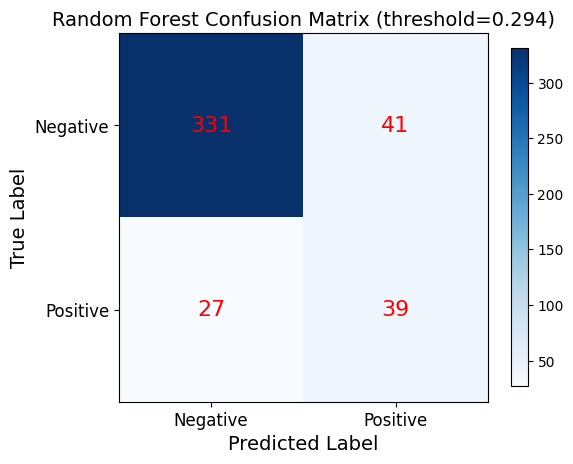

In [9]:
preds = (best_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(shrink=0.6)

classes = ['Negative', 'Positive']
plt.xticks([0, 1], classes, fontsize=12)
plt.yticks([0, 1], classes, fontsize=12)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title(f'{best_name} Confusion Matrix (threshold={best_threshold:.3f})', fontsize=14)

for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()